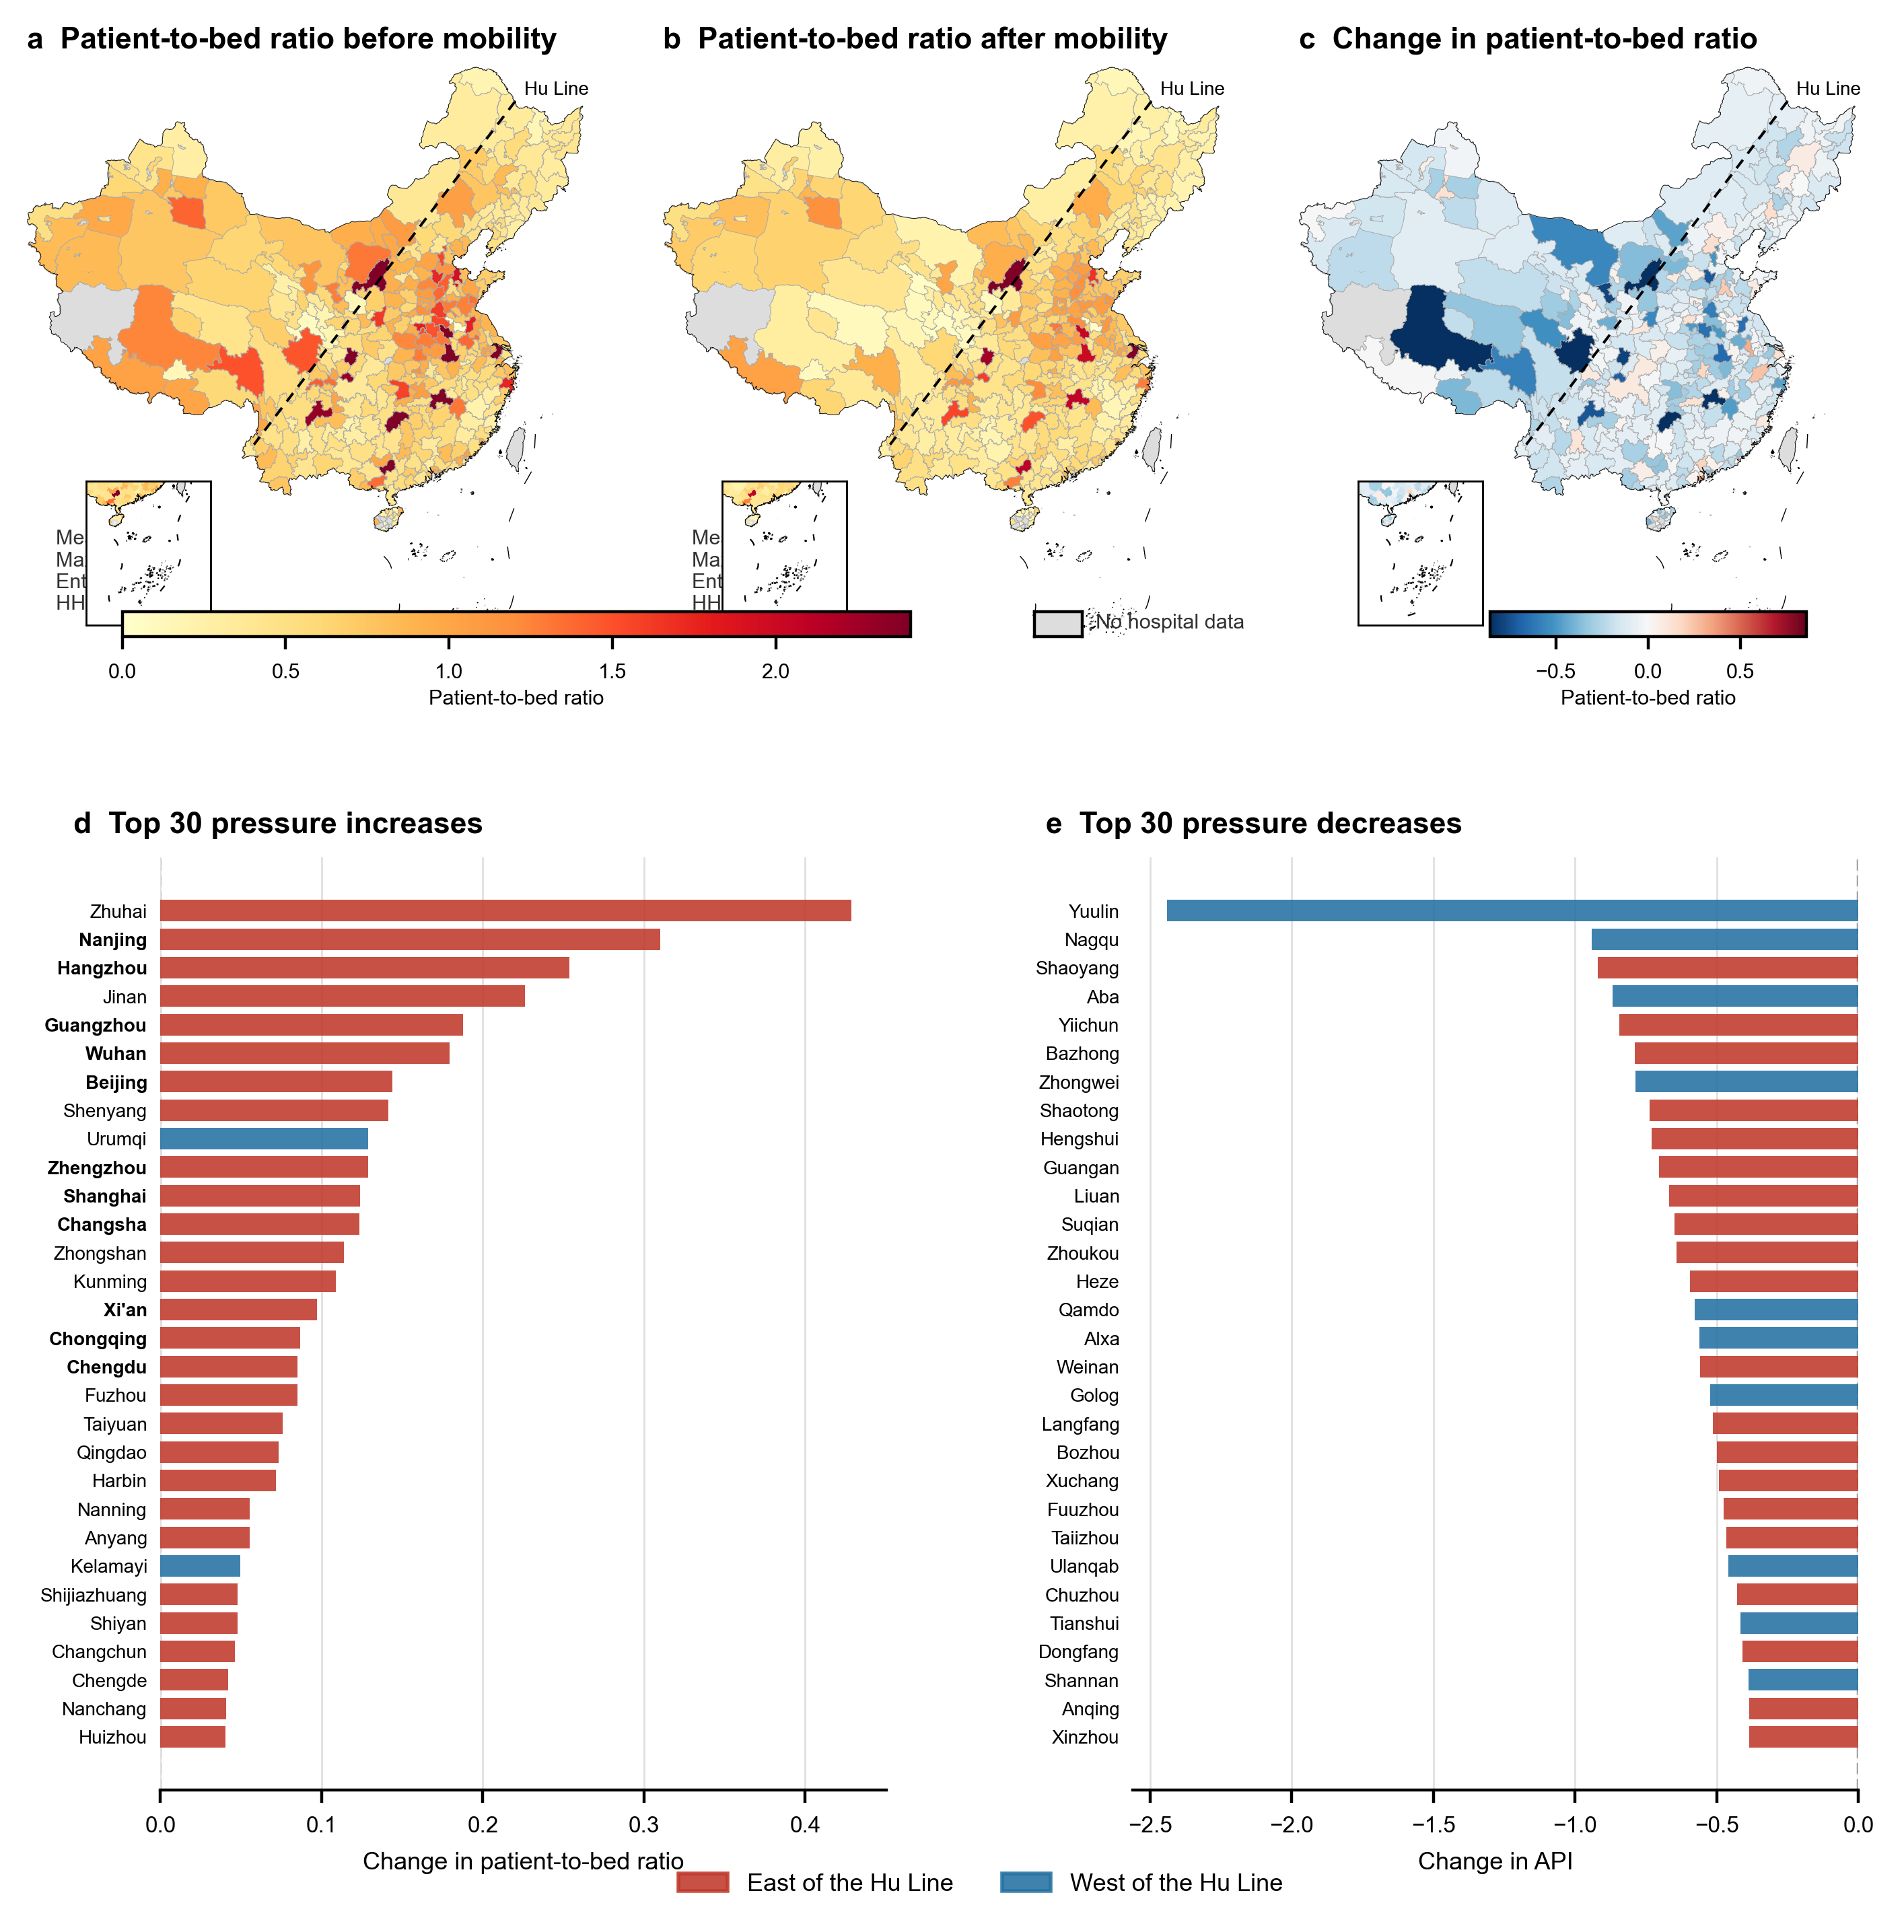

Saved → /Users/shirley/Desktop/plots_V2/Fig4_beds.png


In [1]:
# =============================================================================
# Fig4: Adaptation Pressure Index (API) — 3 maps (Top) + 2 side-by-side bars (Bottom)
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from shapely.geometry import box as shapely_box
from pyproj import Transformer

# ── 0. Paths & settings ───────────────────────────────────────────────────────
FLOW_DIR   = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
LOCAL_DIR  = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5/city_patient_sum")
INPUT_FILE = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/air_pollution/data source/hospital/13-National hospital directory.xlsx")
SHP_PATH   = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2 = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
OUTFILE    = Path("/Users/shirley/Desktop/plots_V2//Fig4_beds.png")

SCENARIO   = "earlypeak_NZ_CL"
YEARS      = [2020, 2030, 2040, 2050, 2060]

CITY_NAME_MAP = {

    "Wulumuqi":   "Urumqi",
    "Xian":       "Xi'an",
    "Qiqihaer":   "Qiqihar",
    "Huhehaote":  "Hohhot",
    "Haerbin":    "Harbin",
    "Xiuqian":    "Suqian",
    "Wulanchabu": "Ulanqab",
    "Shaoang":    "Zhaotong", 
    "Tongcuan":   "Tongchuan", 
    "Xiangfan":   "Xiangyang",   

    "Akesu":        "Aksu",
    "Alaer":        "Alar",
    "Alashan":      "Alxa",
    "Bayanzhuoer":  "Bayannur", 
    "Bayinguoleng": "Bayingolin", 
    "Boertalameng": "Bortala",    
    "Changdu":      "Qamdo",      
    "Eerduosi":     "Erdos", 
    "Ordos":      "Erdos", 
    "Guoluo":       "Golog", 
    "Guolo":      "Golog", 
    "Hulunbeier":   "Hulunbuir", 
    "Kezilesu":     "Kizilsu",    
    "Ledong":       "Ledong",     
    "Lingshui":     "Lingshui",   
    "Linzhi":       "Nyingchi",  
    "Naqu":         "Nagqu",      
    "Qiongzhong":   "Qiongzhong", 
    "Shennongjia":  "Shennongjia",
    "Tumushuke":    "Tumxuk",      
    "Xilinguole":   "Xilingol",    
    "Xingan":       "Hinggan",     

}

BOLD_CITIES = {
   "Beijing", "Shanghai", "Guangzhou", "Tianjin", "Hangzhou", "Nanjing", 
   "Wuhan", "Zhengzhou", "Chongqing", "Xi'an", "Chengdu", "Shenzhen", "Changsha"
}

C_EAST   = "#C0392B"
C_WEST   = "#2471A3"
C_NODATA = "#DDDDDD" 
PROJ_STR = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})

# ── 2. Spatial data ───────────────────────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)

city_shp_raw = gpd.read_file(SHP_PATH)
city_shp_raw["English"] = city_shp_raw["English"].str.strip().map(
    lambda x: CITY_NAME_MAP.get(x, x))
city_shp = city_shp_raw.to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y  = _hhy_transformer.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = city_shp.geometry.centroid.x
_cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")

region_map = (
    city_shp[["English", "region"]]
    .drop_duplicates(subset="English")
    .set_index("English")["region"]
    .to_dict()
)

# ── 3. Data loaders ───────────────────────────────────────────────────────────
def rename_idx(idx):
    return idx.str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))

def load_flow_matrix(year):
    path = FLOW_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = rename_idx(df.index)
    df.columns = rename_idx(df.columns)
    df = df.loc[~df.index.isin(["total"]), ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    return df

def load_citysum(year):
    path = LOCAL_DIR / f"citysum_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path)
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["local_patient", "mo_total"]].sum()

def compute_year(year):
    df_flow  = load_flow_matrix(year)
    df_local = load_citysum(year)
    
    inflow   = df_flow.sum(axis=0).groupby(level=0).sum()
    outflow  = df_flow.sum(axis=1).groupby(level=0).sum()
    
    all_cities = inflow.index.union(outflow.index)
    inflow   = inflow.reindex(all_cities,  fill_value=0)
    outflow  = outflow.reindex(all_cities, fill_value=0)
    
    net = (inflow - outflow).rename("net")
    
    df_local = df_local.groupby(level=0).sum()
    common   = net.index.intersection(df_local.index)
    out = df_local.loc[common].copy()
    
    out["net"] = net.loc[common].values
    city_inflow = inflow.reindex(out.index, fill_value=0).values
    
    raw_demand = np.where(
        city_inflow > 0,
        out["local_patient"] + out["net"],  
        out["local_patient"]               
    )
    out["demand"] = np.where(raw_demand < 0, 0.0, raw_demand)
    
    if "mo_total" in out.columns:
        out["mo_total"] = np.where(out["mo_total"] < 0, 0.0, out["mo_total"])
        
    return out

# ── 4. Resource Loader ────────────────────────────────────────────────────────
def load_resource():
    df = pd.read_excel(INPUT_FILE, sheet_name="fig4")
    df = df[["city", "beds", "clinics"]].copy()
    df["beds"]    = pd.to_numeric(df["beds"],    errors="coerce")
    df["clinics"] = pd.to_numeric(df["clinics"], errors="coerce")
    df = df.dropna(subset=["city", "beds", "clinics"])
    df = df[(df["beds"] > 0) & (df["clinics"] > 0)]
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    df["resource"] = np.log(df["beds"] * df["clinics"])
    return df.groupby("city")["beds"].sum()

# ── 5. Compute API Data, Entropy, and HHI (NaN 严格防御) ──────────────────────
resource = load_resource()
frames   = [compute_year(y) for y in YEARS]
avg      = pd.concat(frames).groupby(level=0).mean()

common   = avg.index.intersection(resource.index)
avg      = avg.loc[common]
res      = resource.loc[common]

raw_before = avg["mo_total"] / res
raw_after  = avg["demand"]   / res

global_max = max(raw_before.max(), raw_after.max())

avg["API_before"] = raw_before #/ global_max
avg["API_after"]  = raw_after  #/ global_max
avg["delta_API"]  = avg["API_after"] - avg["API_before"]
avg["region"]     = avg.index.map(region_map)

avg["API_before"] = raw_before #/ global_max
avg["API_after"]  = raw_after  #/ global_max
avg["delta_API"]  = avg["API_after"] - avg["API_before"]
avg["region"]     = avg.index.map(region_map)
 
def compute_network_metrics(series):
    clean_s = series.dropna() 
    arr = clean_s.values.astype(np.float64)
    arr = arr[arr > 0]
    if len(arr) == 0: 
        return 0.0, 0.0
    
    p = arr / np.sum(arr)
    entropy = -np.sum(p * np.log(p))
    hhi = np.sum(p ** 2)
    return entropy, hhi
 
entropy_before, hhi_before = compute_network_metrics(avg["API_before"])
entropy_after, hhi_after   = compute_network_metrics(avg["API_after"])
 
# Sorting for horizontal bar charts
df_diff  = avg.dropna(subset=["delta_API"]).sort_values("delta_API", ascending=False).copy()
df_top30 = df_diff.head(30).copy()
df_bot30 = df_diff.tail(30).sort_values("delta_API", ascending=True).copy()
 
# ── 6. Merge with shapefile ───────────────────────────────────────────────────
avg_reset = avg[["API_before", "API_after", "delta_API", "region"]].reset_index().rename(columns={"index": "city"})
shp = city_shp.merge(avg_reset, left_on="English", right_on="city", how="left")
 
# ── 6b. Color scale range for panels a & b ────────────────────────────────────
# API is no longer normalized to a fixed 0–1 range, so the color scale must be
# derived from the actual data instead of a hardcoded Normalize(0, 1).
# Uses the 98th percentile across both before/after so a handful of extreme
# outlier cities don't wash out the color scale for everyone else.
vmin_api = 0
vmax_api = max(avg["API_before"].quantile(0.98), avg["API_after"].quantile(0.98))
 
# ── 7. Nanhai inset helper ────────────────────────────────────────────────────
def _add_nanhai_inset(parent_ax, target_shp, col, norm, cmap):
    x1, y1, x2, y2 = _NANHAI_BOUNDS
    axins = parent_ax.inset_axes([0.1, 0.02, 0.22, 0.25])
    axins.set_facecolor("white")
    
    target_shp.plot(column=col, ax=axins, cmap=cmap, norm=norm,
                    linewidth=0, missing_kwds={"color": C_NODATA, "edgecolor": "none"})
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in axins.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("black")
 
# ── 8. Map drawing helpers ────────────────────────────────────────────────────
def _map_base(ax, col, norm, cmap, title, panel):
    """Draw base map layers shared by all three maps."""
    shp.plot(column=col, ax=ax, cmap=cmap, norm=norm,
             linewidth=0.15, edgecolor="#AAAAAA",
             missing_kwds={"color": C_NODATA, "edgecolor": "#AAAAAA"})
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.25)
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.7,
            linestyle="--", dashes=(4, 3), zorder=5)
    ax.text(_HHY_X[0] + 80000, _HHY_Y[0] + 60000,
            "Hu Line", fontsize=5, color="black", zorder=5)
    xmin, ymin, xmax, ymax = china_border.total_bounds
    height = ymax - ymin
    width  = xmax - xmin
    ax.set_xlim(xmin, xmax + width * 0.04)
    ax.set_ylim(ymin + height * 0.10, ymax + height * 0.01)
    ax.set_axis_off()
    ax.text(-0, 1.01, f"{panel}  {title}",
            transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom", ha="left")
    _add_nanhai_inset(ax, shp, col, norm, cmap)
 
def draw_map(ax, col, title, panel, current_entropy, current_hhi):
    """Standard map (YlOrRd) with dynamic entropy and HHI annotation."""
    norm = Normalize(vmin=vmin_api, vmax=vmax_api)
    cmap = "YlOrRd"
    _map_base(ax, col, norm, cmap, title, panel)
    
    v = avg[col].dropna()
    mean_v, max_v = v.mean(), v.max()
    ax.text(0.05, 0.04,
            f"Mean = {mean_v:.2f}\nMax = {max_v:.2f}\nEntropy = {current_entropy:.3f}\nHHI = {current_hhi:.4f}",
            transform=ax.transAxes, fontsize=5.5, color="#333333", va="bottom", ha="left")
 
def draw_diff_map(ax, title, panel):
    """Diverging map for ΔAPI."""
    dmax  = shp["delta_API"].abs().quantile(0.99)
    norm  = TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
    cmap  = "RdBu_r"  
    _map_base(ax, "delta_API", norm, cmap, title, panel)
    return norm, cmap
 
# ── 9. Grid Layout Engineering (优化：下移地图底边，上移条形图顶边) ─────────────
fig = plt.figure(figsize=(18 / 2.54, 20 / 2.54), dpi=400, facecolor="white")
 
 
gs_maps = GridSpec(
    1, 3, figure=fig, hspace=0.0, wspace=0.10, left=0, right=0.97, top=0.97, bottom=0.51,
)
ax_mapA = fig.add_subplot(gs_maps[0, 0])
ax_mapB = fig.add_subplot(gs_maps[0, 1])
ax_mapC = fig.add_subplot(gs_maps[0, 2])
 
gs_bars = GridSpec(
    1, 2, figure=fig, width_ratios=[1, 1], hspace=0.0, wspace=0.34, left=0.07, right=0.96, top=0.50, bottom=0.06,
)
ax_barD1 = fig.add_subplot(gs_bars[0, 0]) 
ax_barD2 = fig.add_subplot(gs_bars[0, 1]) 
 
# ── 10. Draw maps ───────────────────────────────────────────
draw_map(ax_mapA, "API_before", "Patient-to-bed ratio before mobility", "a", entropy_before, hhi_before)
draw_map(ax_mapB, "API_after",  "Patient-to-bed ratio after mobility",  "b", entropy_after, hhi_after)
norm_diff, cmap_diff = draw_diff_map(ax_mapC, "Change in patient-to-bed ratio", "c")
 
# ── 11. Clean Horizontal Colorbars with Edge-Off No Data Legend ─────────────
fig.canvas.draw()
pos_a = ax_mapA.get_position()
pos_b = ax_mapB.get_position()
pos_c = ax_mapC.get_position()
 
cbar_h      = 0.012
 
cbar_bottom = pos_a.y0 
 
cbar_ax_ab = fig.add_axes([pos_a.x0 + 0.05, cbar_bottom, (pos_b.x1 * 0.8 - (pos_a.x0 + 0.05)) * 0.9, cbar_h])
sm_ab = mcm.ScalarMappable(cmap="YlOrRd", norm=Normalize(vmin=vmin_api, vmax=vmax_api))
sm_ab.set_array([])
cbar_ab = fig.colorbar(sm_ab, cax=cbar_ax_ab, orientation="horizontal")
cbar_ab.ax.tick_params(labelsize=5.5)
cbar_ab.set_label("Patient-to-bed ratio", fontsize=5.5, labelpad=2)
 
rect_ax_ab = fig.add_axes([(pos_b.x1 * 0.8 - (pos_a.x0 + 0.05))*1.15 , cbar_bottom , 0.025, cbar_h])
rect_ax_ab.patch.set_facecolor(C_NODATA)
rect_ax_ab.patch.set_edgecolor("#AAAAAA")
rect_ax_ab.patch.set_linewidth(0.3)
rect_ax_ab.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
fig.text(pos_b.x1 * 0.88, cbar_bottom + 0.002, "No hospital data", fontsize=5.5, color="#333333", va="bottom")
 
cbar_ax_c = fig.add_axes([pos_c.x0 * 1.15, cbar_bottom, (pos_c.x1 * 0.95 - pos_c.x0 * 1.05) * 0.75, cbar_h])
sm_c = mcm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
sm_c.set_array([])
cbar_c = fig.colorbar(sm_c, cax=cbar_ax_c, orientation="horizontal")
cbar_c.ax.tick_params(labelsize=5.5)
cbar_c.set_label("Patient-to-bed ratio", fontsize=5.5, labelpad=2)
 
# ── 12. Bar style helper ──────────────────────────────────────────────────────
def style_bar(ax, title, xlabel):
    ax.text(-0.12, 1.02, title, transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom", ha="left")
    ax.set_xlabel(xlabel, fontsize=6.5)
    ax.axvline(0, color="#888", lw=0.8, ls="--", zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=6.5)
    ax.tick_params(axis="x", labelsize=6)
    ax.grid(axis="x", color="#E0E0E0", lw=0.5, zorder=0)
    ax.set_facecolor("white")
 
# ── 13. Subpanel d1: Top 30 Pressure Increases (Horizontal Parallel Left) ───
style_bar(ax_barD1, "d  Top 30 pressure increases", "Change in patient-to-bed ratio")
n_t = len(df_top30)
y_t = np.arange(n_t)
colors_t = [C_EAST if r == "East" else C_WEST for r in df_top30["region"]]
 
ax_barD1.barh(y_t, df_top30["delta_API"].values, color=colors_t, height=0.76, alpha=0.88, zorder=2)
ax_barD1.set_yticks(y_t)
ax_barD1.set_yticklabels(df_top30.index, fontsize=5)
 
for label in ax_barD1.get_yticklabels():
    if label.get_text() in BOLD_CITIES:
        label.set_weight("bold")
        label.set_color("black")
ax_barD1.invert_yaxis() 
 
# ── 14. Subpanel d2: Top 30 Pressure Decreases (Horizontal Parallel Right) ──
style_bar(ax_barD2, "e  Top 30 pressure decreases", "Change in API")
n_b = len(df_bot30)
y_b = np.arange(n_b)
colors_b = [C_EAST if r == "East" else C_WEST for r in df_bot30["region"]]
 
ax_barD2.barh(y_b, df_bot30["delta_API"].values, color=colors_b, height=0.76, alpha=0.88, zorder=2)
ax_barD2.set_yticks(y_b)
ax_barD2.set_yticklabels(df_bot30.index, fontsize=5)
 
for label in ax_barD2.get_yticklabels():
    if label.get_text() in BOLD_CITIES:
        label.set_weight("bold")
        label.set_color("black")
ax_barD2.invert_yaxis() 
 
# ── 15. Shared geographic legend ──────────────────────────────────────────────
patch_e = mpatches.Patch(color=C_EAST, label="East of the Hu Line", alpha=0.88)
patch_w = mpatches.Patch(color=C_WEST, label="West of the Hu Line", alpha=0.88)
fig.legend(handles=[patch_e, patch_w], loc="lower center", ncol=2,
           fontsize=6.5, frameon=False, bbox_to_anchor=(0.5, 0.0))
 
# ── 16. Export and Render ─────────────────────────────────────────────────────
OUTFILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTFILE, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUTFILE}")
 

In [14]:

df_all_cities_export = avg[[
    "region", 
    "mo_total", 
    "demand", 
    "API_before", 
    "API_after", 
    "delta_API"
]].copy()


df_all_cities_export = df_all_cities_export.rename(columns={
    "mo_total": "patients_before_mobility",
    "demand": "patients_after_mobility",
    "API_before": "API_before_mobility",
    "API_after": "API_after_mobility",
    "delta_API": "change_in_API"
})


df_all_cities_export.index.name = "city_name"


ALL_CITIES_CSV_OUT = OUTFILE.parent / "Fig4_All_Cities_API_Database.csv"


df_all_cities_export.to_csv(ALL_CITIES_CSV_OUT, encoding="utf-8-sig")


In [ ]:
# =============================================================================
# Fig4: Patient counts (Top) + Patient-to-bed ratio (Middle) + Income-group bars (Bottom)
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from shapely.geometry import box as shapely_box
from pyproj import Transformer

# ── 0. Paths & settings ───────────────────────────────────────────────────────
FLOW_DIR   = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
LOCAL_DIR  = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5/city_patient_sum")
INPUT_FILE = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/air_pollution/data source/hospital/13-National hospital directory.xlsx")
SHP_PATH   = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2 = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
OUTFILE    = Path("/Users/shirley/Desktop/plots_V2/Fig3_beds.png")

INCOME_DIR       = Path("/Volumes/UCL/论文工作/空气污染/weighted_gdp/avg_fer_rcp/avg_2020.csv")

INCOME_CITY_COL  = "city"
INCOME_CLASS_COL = "income_group"
GDP_CLASS_ORDER  = ["Low", "Lower middle", "Middle", "Upper middle", "High"]
GDP_CLASS_COLORS = ["#D6EFD6", "#A8DDA8", "#6FC26F", "#3B9E3B", "#1B6B1B"]  # light->dark green, matches Fig1 style

SCENARIO   = "earlypeak_NZ_CL"
YEARS      = [2020, 2030, 2040, 2050, 2060]

CITY_NAME_MAP = {
    "Wulumuqi":   "Urumqi",
    "Xian":       "Xi'an",
    "Qiqihaer":   "Qiqihar",
    "Huhehaote":  "Hohhot",
    "Haerbin":    "Harbin",
    "Xiuqian":    "Suqian",
    "Wulanchabu": "Ulanqab",
    "Shaoang":    "Zhaotong",
    "Tongcuan":   "Tongchuan",
    "Xiangfan":   "Xiangyang",
    "Akesu":        "Aksu",
    "Alaer":        "Alar",
    "Alashan":      "Alxa",
    "Bayanzhuoer":  "Bayannur",
    "Bayinguoleng": "Bayingolin",
    "Boertalameng": "Bortala",
    "Changdu":      "Qamdo",
    "Eerduosi":     "Erdos",
    "Ordos":      "Erdos",
    "Guoluo":       "Golog",
    "Guolo":      "Golog",
    "Hulunbeier":   "Hulunbuir",
    "Kezilesu":     "Kizilsu",
    "Ledong":       "Ledong",
    "Lingshui":     "Lingshui",
    "Linzhi":       "Nyingchi",
    "Naqu":         "Nagqu",
    "Qiongzhong":   "Qiongzhong",
    "Shennongjia":  "Shennongjia",
    "Tumushuke":    "Tumxuk",
    "Xilinguole":   "Xilingol",
    "Xingan":       "Hinggan",
}

BOLD_CITIES = {
   "Beijing", "Shanghai", "Guangzhou", "Tianjin", "Hangzhou", "Nanjing",
   "Wuhan", "Zhengzhou", "Chongqing", "Xi'an", "Chengdu", "Shenzhen", "Changsha"
}

C_EAST   = "#C0392B"
C_WEST   = "#2471A3"
C_NODATA = "#DDDDDD"
PROJ_STR = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})

# ── 2. Spatial data ───────────────────────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)

city_shp_raw = gpd.read_file(SHP_PATH)
city_shp_raw["English"] = city_shp_raw["English"].str.strip().map(
    lambda x: CITY_NAME_MAP.get(x, x))
city_shp = city_shp_raw.to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y  = _hhy_transformer.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = city_shp.geometry.centroid.x
_cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")

region_map = (
    city_shp[["English", "region"]]
    .drop_duplicates(subset="English")
    .set_index("English")["region"]
    .to_dict()
)

# ── 3. Data loaders ───────────────────────────────────────────────────────────
def rename_idx(idx):
    return idx.str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))

def load_flow_matrix(year):
    path = FLOW_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = rename_idx(df.index)
    df.columns = rename_idx(df.columns)
    df = df.loc[~df.index.isin(["total"]), ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    return df

def load_citysum(year):
    path = LOCAL_DIR / f"citysum_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path)
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["local_patient", "mo_total"]].sum()

def compute_year(year):
    df_flow  = load_flow_matrix(year)
    df_local = load_citysum(year)

    inflow   = df_flow.sum(axis=0).groupby(level=0).sum()
    outflow  = df_flow.sum(axis=1).groupby(level=0).sum()

    all_cities = inflow.index.union(outflow.index)
    inflow   = inflow.reindex(all_cities,  fill_value=0)
    outflow  = outflow.reindex(all_cities, fill_value=0)

    net = (inflow - outflow).rename("net")

    df_local = df_local.groupby(level=0).sum()
    common   = net.index.intersection(df_local.index)
    out = df_local.loc[common].copy()

    out["net"] = net.loc[common].values
    city_inflow = inflow.reindex(out.index, fill_value=0).values

    raw_demand = np.where(
        city_inflow > 0,
        out["local_patient"] + out["net"],
        out["local_patient"]
    )
    out["demand"] = np.where(raw_demand < 0, 0.0, raw_demand)

    if "mo_total" in out.columns:
        out["mo_total"] = np.where(out["mo_total"] < 0, 0.0, out["mo_total"])

    return out

# ── 4. Resource & income-class loaders ────────────────────────────────────────
def load_resource():
    df = pd.read_excel(INPUT_FILE, sheet_name="fig4")
    df = df[["city", "beds", "clinics"]].copy()
    df["beds"]    = pd.to_numeric(df["beds"],    errors="coerce")
    df["clinics"] = pd.to_numeric(df["clinics"], errors="coerce")
    df = df.dropna(subset=["city", "beds", "clinics"])
    df = df[(df["beds"] > 0) & (df["clinics"] > 0)]
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    df["resource"] = np.log(df["beds"] * df["clinics"])
    return df.groupby("city")["beds"].sum()

def load_gdp_class():
    """
    Reads the pre-existing income_group classification from avg_2020.csv
    (consistent with Fig. 1c). TODO: confirm INCOME_CITY_COL matches the
    actual city-name column, and that the category labels in income_group
    match GDP_CLASS_ORDER exactly (case/wording).
    """
    df = pd.read_csv(INCOME_DIR)
    df[INCOME_CITY_COL] = df[INCOME_CITY_COL].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    df = df.dropna(subset=[INCOME_CITY_COL, INCOME_CLASS_COL])
    df["gdp_class"] = pd.Categorical(df[INCOME_CLASS_COL], categories=GDP_CLASS_ORDER, ordered=True)
    return df.set_index(INCOME_CITY_COL)["gdp_class"]

# ── 5. Compute API data, entropy, HHI ─────────────────────────────────────────
resource   = load_resource()
gdp_class  = load_gdp_class()
frames     = [compute_year(y) for y in YEARS]
avg        = pd.concat(frames).groupby(level=0).mean()

common = avg.index.intersection(resource.index)
avg    = avg.loc[common]
res    = resource.loc[common]

raw_before = avg["mo_total"] / res
raw_after  = avg["demand"]   / res

avg["API_before"] = raw_before
avg["API_after"]  = raw_after
avg["delta_API"]  = avg["API_after"] - avg["API_before"]
avg["region"]     = avg.index.map(region_map)
avg["gdp_class"]  = avg.index.map(gdp_class)

def compute_network_metrics(series):
    clean_s = series.dropna()
    arr = clean_s.values.astype(np.float64)
    arr = arr[arr > 0]
    if len(arr) == 0:
        return 0.0, 0.0
    p = arr / np.sum(arr)
    entropy = -np.sum(p * np.log(p))
    hhi = np.sum(p ** 2)
    return entropy, hhi

entropy_before, hhi_before = compute_network_metrics(avg["API_before"])
entropy_after, hhi_after   = compute_network_metrics(avg["API_after"])

# ── 5b. Tail-risk / overload analysis ─────────────────────────────────────────
# τ (tau): a data-driven "danger threshold" — cities whose pre-mobility API sits
# in the far right tail are treated as "severely overloaded". Using a percentile
# of the BEFORE distribution (not after) keeps τ fixed and externally meaningful:
# it answers "how many cities are as bad as pre-mobility's worst 10%, once
# mobility has happened?" rather than a threshold that itself shifts with the data.
TAU_PERCENTILE = 0.90
tau = avg["API_before"].quantile(TAU_PERCENTILE)

def overload_stats(series, tau, beds=None):
    excess = (series - tau).clip(lower=0)
    n_over   = int((series > tau).sum())
    pct_over = 100 * n_over / series.notna().sum()
    total_excess = excess.sum() if beds is None else (excess * beds).sum()
    return {
        "n_over_tau":      n_over,
        "pct_cities_over": pct_over,
        "total_excess":    total_excess,
        "p90":             series.quantile(0.90),
        "p95":             series.quantile(0.95),
        "p99":             series.quantile(0.99),
        "max":             series.max(),
    }

stats_before = overload_stats(avg["API_before"], tau, beds=res)
stats_after  = overload_stats(avg["API_after"],  tau, beds=res)

print(f"\n=== Tail-risk summary (τ = {TAU_PERCENTILE:.0%} of pre-mobility API = {tau:.3f}) ===")
print(f"{'metric':<20}{'before':>12}{'after':>12}{'change':>12}")
for k in stats_before:
    b, a = stats_before[k], stats_after[k]
    print(f"{k:<20}{b:>12.3f}{a:>12.3f}{(a-b):>12.3f}")

# Optional: how many cities that were OVER τ before mobility dropped BELOW it after
relieved = avg[(avg["API_before"] > tau) & (avg["API_after"] <= tau)]
newly_over = avg[(avg["API_before"] <= tau) & (avg["API_after"] > tau)]
print(f"\nCities relieved from overload (were>τ, now≤τ): {len(relieved)}")
print(f"Cities newly pushed into overload (were≤τ, now>τ): {len(newly_over)}")

# ── 6. Merge with shapefile ────────────────────────────────────────────────────
avg_reset = avg[["mo_total", "demand", "net", "API_before", "API_after",
                 "delta_API", "region", "gdp_class"]].reset_index().rename(columns={"index": "city"})
shp = city_shp.merge(avg_reset, left_on="English", right_on="city", how="left")

# ── 6b. Color-scale ranges ─────────────────────────────────────────────────────
vmin_api = 0
vmax_api = max(avg["API_before"].quantile(0.98), avg["API_after"].quantile(0.98))

vmin_patient = 0
vmax_patient = max(avg["mo_total"].quantile(0.98), avg["demand"].quantile(0.98))

dmax_net = shp["net"].abs().quantile(0.99)
dmax_api = shp["delta_API"].abs().quantile(0.99)

# ── 7. Nanhai inset helper ─────────────────────────────────────────────────────
def _add_nanhai_inset(parent_ax, target_shp, col, norm, cmap):
    x1, y1, x2, y2 = _NANHAI_BOUNDS
    axins = parent_ax.inset_axes([0.83, 0.01, 0.15, 0.18])
    axins.set_facecolor("white")
    target_shp.plot(column=col, ax=axins, cmap=cmap, norm=norm,
                    linewidth=0, missing_kwds={"color": C_NODATA, "edgecolor": "none"})
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in axins.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("black")

# ── 8. Map drawing helpers ─────────────────────────────────────────────────────
def _map_base(ax, col, norm, cmap, title, panel, show_hu_label=False):
    shp.plot(column=col, ax=ax, cmap=cmap, norm=norm,
             linewidth=0.15, edgecolor="#AAAAAA",
             missing_kwds={"color": C_NODATA, "edgecolor": "#AAAAAA"})
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.25)
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.7,
            linestyle="--", dashes=(4, 3), zorder=5)
    if show_hu_label:
        ax.text(_HHY_X[0] + 80000, _HHY_Y[0] + 60000,
                "Hu Line", fontsize=5, color="black", zorder=5)
    xmin, ymin, xmax, ymax = china_border.total_bounds
    height = ymax - ymin
    width  = xmax - xmin
    ax.set_xlim(xmin, xmax + width * 0.04)
    ax.set_ylim(ymin + height * 0.10, ymax + height * 0.01)
    ax.set_axis_off()
    ax.text(-0, 1.01, f"{panel}  {title}",
            transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom", ha="left")
    _add_nanhai_inset(ax, shp, col, norm, cmap)

def draw_seq_map(ax, col, title, panel, norm, cmap="YlOrRd", stat_text=None, show_hu_label=False):
    _map_base(ax, col, norm, cmap, title, panel, show_hu_label)
    if stat_text:
        ax.text(0.05, 0.04, stat_text, transform=ax.transAxes,
                fontsize=5.5, color="#333333", va="bottom", ha="left")
        

def draw_diff_map(ax, col, title, panel, dmax, cmap="RdBu_r", show_hu_label=False):
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
    _map_base(ax, col, norm, cmap, title, panel, show_hu_label)
    return norm, cmap

# ── 9. Grid layout: 3 rows (maps, maps, income-group bars) ────────────────────
fig = plt.figure(figsize=(18 / 2.54, 18 / 2.54), dpi=400, facecolor="white")

gs_row1 = GridSpec(1, 3, figure=fig, wspace=0.10, left=0, right=0.97, top=0.98, bottom=0.65)
gs_row2 = GridSpec(1, 3, figure=fig, wspace=0.10, left=0, right=0.97, top=0.65, bottom=0.33)
gs_row3 = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.33, left=0.09, right=0.96, top=0.24, bottom=0.06)

ax_r1a = fig.add_subplot(gs_row1[0, 0])
ax_r1b = fig.add_subplot(gs_row1[0, 1])
ax_r1c = fig.add_subplot(gs_row1[0, 2])

ax_r2a = fig.add_subplot(gs_row2[0, 0])
ax_r2b = fig.add_subplot(gs_row2[0, 1])
ax_r2c = fig.add_subplot(gs_row2[0, 2])

ax_barF = fig.add_subplot(gs_row3[0, 0])
ax_barG = fig.add_subplot(gs_row3[0, 1])

# ── 10. Row 1 — patient counts ────────────────────────────────────────────────
norm_patient = Normalize(vmin=vmin_patient, vmax=vmax_patient)
draw_seq_map(ax_r1a, "mo_total", "Patients before mobility", "a", norm_patient,
             cmap="YlOrRd", show_hu_label=True)
draw_seq_map(ax_r1b, "demand", "Patients after mobility", "b", norm_patient, cmap="YlOrRd")
norm_net, cmap_net = draw_diff_map(ax_r1c, "net", "Net inflow patients", "c", dmax_net)

# ── 11. Row 2 — patient-to-bed ratio ──────────────────────────────────────────
norm_api = Normalize(vmin=vmin_api, vmax=vmax_api)
draw_seq_map(ax_r2a, "API_before", "Patient-to-bed ratio before mobility", "d", norm_api, cmap="YlOrRd")
draw_seq_map(ax_r2b, "API_after", "Patient-to-bed ratio after mobility", "e", norm_api, cmap="YlOrRd"
            )
norm_api_diff, cmap_api_diff = draw_diff_map(ax_r2c, "delta_API", "Change in patient-to-bed ratio", "f", dmax_api)

# ── 12. Colorbars for row 1 and row 2 ─────────────────────────────────────────
fig.canvas.draw()

def add_row_colorbars(ax_left, ax_mid, ax_right, norm_seq, cmap_seq, norm_diff, cmap_diff,
                       label_seq, label_diff, y_offset=0.02):
    pos_l = ax_left.get_position()
    pos_m = ax_mid.get_position()
    pos_r = ax_right.get_position()
    cbar_h = 0.010
    cbar_bottom = pos_l.y0 - y_offset

    cbar_ax_lm = fig.add_axes([pos_l.x0 + 0.05, cbar_bottom,
                               (pos_m.x1 * 0.8 - (pos_l.x0 + 0.05)) * 0.9, cbar_h])
    sm_lm = mcm.ScalarMappable(cmap=cmap_seq, norm=norm_seq)
    sm_lm.set_array([])
    cbar_lm = fig.colorbar(sm_lm, cax=cbar_ax_lm, orientation="horizontal")
    cbar_lm.ax.tick_params(labelsize=5.5)
    cbar_lm.set_label(label_seq, fontsize=5.5, labelpad=2)

    rect_ax = fig.add_axes([(pos_m.x1 * 0.8 - (pos_l.x0 + 0.05)) * 1.15, cbar_bottom, 0.025, cbar_h])
    rect_ax.patch.set_facecolor(C_NODATA)
    rect_ax.patch.set_edgecolor("#AAAAAA")
    rect_ax.patch.set_linewidth(0.3)
    rect_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    fig.text(pos_m.x1 * 0.88, cbar_bottom + 0.002, "No hospital data", fontsize=5.5, color="#333333", va="bottom")

    cbar_ax_r = fig.add_axes([pos_r.x0 * 1.15, cbar_bottom, (pos_r.x1 * 0.95 - pos_r.x0 * 1.05) * 0.75, cbar_h])
    sm_r = mcm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
    sm_r.set_array([])
    cbar_r = fig.colorbar(sm_r, cax=cbar_ax_r, orientation="horizontal")
    cbar_r.ax.tick_params(labelsize=5.5)
    cbar_r.set_label(label_diff, fontsize=5.5, labelpad=2)

add_row_colorbars(ax_r1a, ax_r1b, ax_r1c, norm_patient, "YlOrRd", norm_net, cmap_net,
                   "Patients", "Net inflow patients", y_offset=0.025)
add_row_colorbars(ax_r2a, ax_r2b, ax_r2c, norm_api, "YlOrRd", norm_api_diff, cmap_api_diff,
                   "Patient-to-bed ratio", "Change in patient-to-bed ratio", y_offset=0.025)

# ── 13. Bar style helper ───────────────────────────────────────────────────────
def style_bar(ax, title, ylabel):
    ax.text(-0.12, 1.05, title, transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom", ha="left")
    ax.set_ylabel(ylabel, fontsize=6.5)
    ax.axhline(0, color="#888", lw=0.8, ls="--", zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", length=0, labelsize=6.5)
    ax.tick_params(axis="y", labelsize=6)
    ax.grid(axis="y", color="#E0E0E0", lw=0.5, zorder=0)
    ax.set_facecolor("white")

# ── 14. Row 3 — income-group (GDP per capita class) boxplots ─────────────────
def boxplot_by_class(ax, value_col, title, ylabel):
    data = [avg.loc[avg["gdp_class"] == cls, value_col].dropna().values for cls in GDP_CLASS_ORDER]
    bp = ax.boxplot(data, positions=np.arange(len(GDP_CLASS_ORDER)), widths=0.6,
                     patch_artist=True, showfliers=False,
                     medianprops=dict(color="black", linewidth=1),
                     whiskerprops=dict(color="#555555", linewidth=0.8),
                     capprops=dict(color="#555555", linewidth=0.8))
    for patch, color in zip(bp["boxes"], GDP_CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_edgecolor("#555555")
        patch.set_linewidth(0.6)
    ax.set_xticks(np.arange(len(GDP_CLASS_ORDER)))
    ax.set_xticklabels(GDP_CLASS_ORDER, fontsize=6, rotation=20, ha="right")
    style_bar(ax, title, ylabel)

boxplot_by_class(ax_barF, "net", "g  Net inflow patients by income group", "Net inflow patients")
boxplot_by_class(ax_barG, "delta_API", "h  Patient-to-bed ratio change by income group", "Change in patient-to-bed ratio")

# ── 16. Export and render ─────────────────────────────────────────────────────
OUTFILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTFILE, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUTFILE}")

# ── 17. Supplementary: tail-risk rank-value plot ──────────────────────────────
# Sorts cities by API (descending) and plots the curve before vs after mobility.
# The horizontal line marks τ; the shaded gap between the two curves in the
# right tail is the visual "shrinkage" argument — even where the after-curve
# sits above the before-curve (moderate hubs), the AREA under the curve beyond τ
# should visibly shrink overall, since it's dominated by the tail collapse.
sorted_before = avg["API_before"].sort_values(ascending=False).reset_index(drop=True)
sorted_after  = avg["API_after"].sort_values(ascending=False).reset_index(drop=True)

fig_tail, ax_tail = plt.subplots(figsize=(9 / 2.54, 7 / 2.54), dpi=400)
ax_tail.plot(np.arange(1, len(sorted_before) + 1), sorted_before.values,
             color=C_WEST, lw=1.2, label="Before mobility")
ax_tail.plot(np.arange(1, len(sorted_after) + 1), sorted_after.values,
             color=C_EAST, lw=1.2, label="After mobility")
ax_tail.axhline(tau, color="#888", lw=0.8, ls="--", label=f"τ ({TAU_PERCENTILE:.0%} of before)")
ax_tail.set_xlabel("City rank (descending patient-to-bed ratio)", fontsize=7)
ax_tail.set_ylabel("Patient-to-bed ratio", fontsize=7)
ax_tail.tick_params(labelsize=6.5)
ax_tail.spines[["top", "right"]].set_visible(False)
ax_tail.legend(fontsize=6, frameon=False)
fig_tail.tight_layout()
TAIL_OUTFILE = OUTFILE.parent / "FigS_tail_risk.png"
fig_tail.savefig(TAIL_OUTFILE, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {TAIL_OUTFILE}")